## 🚗 Toyota price predictor - ML pipeline

Predicting Toyota car prices using data scraped from [Kolesa.kz](https://kolesa.kz).
This notebook is a continuation of [`kolesa_scraped.ipynb`](./kolesa_scraped.ipynb) where the data was collected and cleaned.

---

### 1.0 Data load

Load the dataset generated by the scraping notebook.

In [2]:
import pandas as pd
df = pd.read_csv('toyota_data.csv')
df

,Unnamed: 0,Brand,Model,Price,Location,Year,Engine_Liter,Car_Age
0,1,Toyota,Land Cruiser Prado,8900000,Алматы,2004,4.0,21
1,2,Toyota,Land Cruiser,20500000,Алматы,2011,5.7,14
2,3,Toyota,4Runner,14500000,Алматы,2015,4.0,10
3,4,Toyota,Land Cruiser Prado,14500000,Алматы,2008,4.0,17
4,5,Toyota,Land Cruiser Prado,11900000,Алматы,2009,2.7,16
...,...,...,...,...,...,...,...,...
13295,13296,Toyota,Camry,13000000,Семей,2020,2.0,5
13296,13297,Toyota,Carina ED,1600000,Сатпаев,1995,2.0,30
13297,13298,Toyota,Carina E,1250000,Усть-Каменогорск,1992,1.6,33
13298,13299,Toyota,Camry,5200000,Кентау,2000,3.0,25


### 1.1 Drop unused columns

`Unnamed: 0` - index artifact from CSV export. `Brand` is always Toyota, no information value.

In [4]:
df = df.drop(columns=['Unnamed: 0', 'Brand'])
df.head()

,Model,Price,Location,Year,Engine_Liter,Car_Age
0,Land Cruiser Prado,8900000,Алматы,2004,4.0,21
1,Land Cruiser,20500000,Алматы,2011,5.7,14
2,4Runner,14500000,Алматы,2015,4.0,10
3,Land Cruiser Prado,14500000,Алматы,2008,4.0,17
4,Land Cruiser Prado,11900000,Алматы,2009,2.7,16


### 1.2 Checks

Quick sanity check: shape, dtypes, nulls, duplicates, unique counts, and numerical stats before modeling.

In [6]:
# базовая инфа
print(df.shape)
print(df.dtypes)
print()

# nulls
print('Nulls: ')
print(df.isnull().sum())
print()

# dulpicates
print('Duplicates: ')
print("Duplicates:", df.duplicated().sum())
print()

# unique
print("Models:", df['Model'].nunique())
print("Locations:", df['Location'].nunique())
print()

# numerical
print(df.describe())

(13300, 6)
Model            object
Price             int64
Location         object
Year              int64
Engine_Liter    float64
Car_Age           int64
dtype: object

Nulls: 
Model           0
Price           0
Location        0
Year            0
Engine_Liter    0
Car_Age         0
dtype: int64

Duplicates: 
Duplicates: 0

Models: 157
Locations: 156

              Price          Year  Engine_Liter       Car_Age
count  1.330000e+04  13300.000000  13300.000000  13300.000000
mean   1.057782e+07   2009.268346      2.680962     15.731654
std    9.614419e+06      9.004478      0.790024      9.004478
min    1.000000e+04   1983.000000      1.000000      0.000000
25%    4.500000e+06   2003.000000      2.200000      9.000000
50%    7.500000e+06   2010.000000      2.500000     15.000000
75%    1.350000e+07   2016.000000      3.000000     22.000000
max    7.547747e+07   2025.000000      5.700000     42.000000


### 1.3 Outlier detection

Checking the cheapest listings, suspiciously low prices are likely placeholder values (e.g. `10,000 KZT ≈ $20`).

In [8]:
# топ 5 самых дорогих
print(df.nlargest(5, 'Price'))

# 5 самых дешевых
print(df.nsmallest(5, 'Price'))

# price min = 10 000 явно мусор
print(df[df['Price'] < 100000])

                      Model     Price   Location  Year  Engine_Liter  Car_Age
955                 Sequoia  75477466   Павлодар  2025           3.5        0
3159           Land Cruiser  73790000      Тараз  2025           3.5        0
5481  Land Cruiser Premium+  73790000     Алматы  2025           3.5        0
5716  Land Cruiser Premium+  73790000  Караганда  2024           3.5        1
566    Land Cruiser Premium  71990000  Караганда  2025           3.5        0
              Model  Price Location  Year  Engine_Liter  Car_Age
2922          Camry  10000  Шымкент  2024           2.5        1
5026          Camry  10000   Бейнеу  2009           2.5       16
5027          Camry  10000   Бейнеу  2014           2.5       11
6584  Urban Cruiser  10000   Алматы  2015           1.8       10
7059          Camry  10000   Актобе  2010           2.5       15
               Model  Price       Location  Year  Engine_Liter  Car_Age
2922           Camry  10000        Шымкент  2024           2.5        

In [9]:
print(df[df['Price'] < 100000].shape)
print(df[df['Price'] < 100000])


(8, 6)
               Model  Price       Location  Year  Engine_Liter  Car_Age
2922           Camry  10000        Шымкент  2024           2.5        1
5026           Camry  10000         Бейнеу  2009           2.5       16
5027           Camry  10000         Бейнеу  2014           2.5       11
6584   Urban Cruiser  10000         Алматы  2015           1.8       10
7059           Camry  10000         Актобе  2010           2.5       15
7272           Ipsum  10000        Уральск  2004           2.4       21
9857           Camry  10000         Алматы  2015           2.5       10
10190        Corolla  10000  Петропавловск  1984           1.3       41


### 1.4 Remove outliers

Drop listings with `Price < 100,000 KZT` - these are clearly invalid entries.

In [11]:
df = df[df['Price'] >= 100000].copy()
print(df.shape)

(13292, 6)


### 2.0 EDA - visualization

Exploring price distributions and key relationships before training.

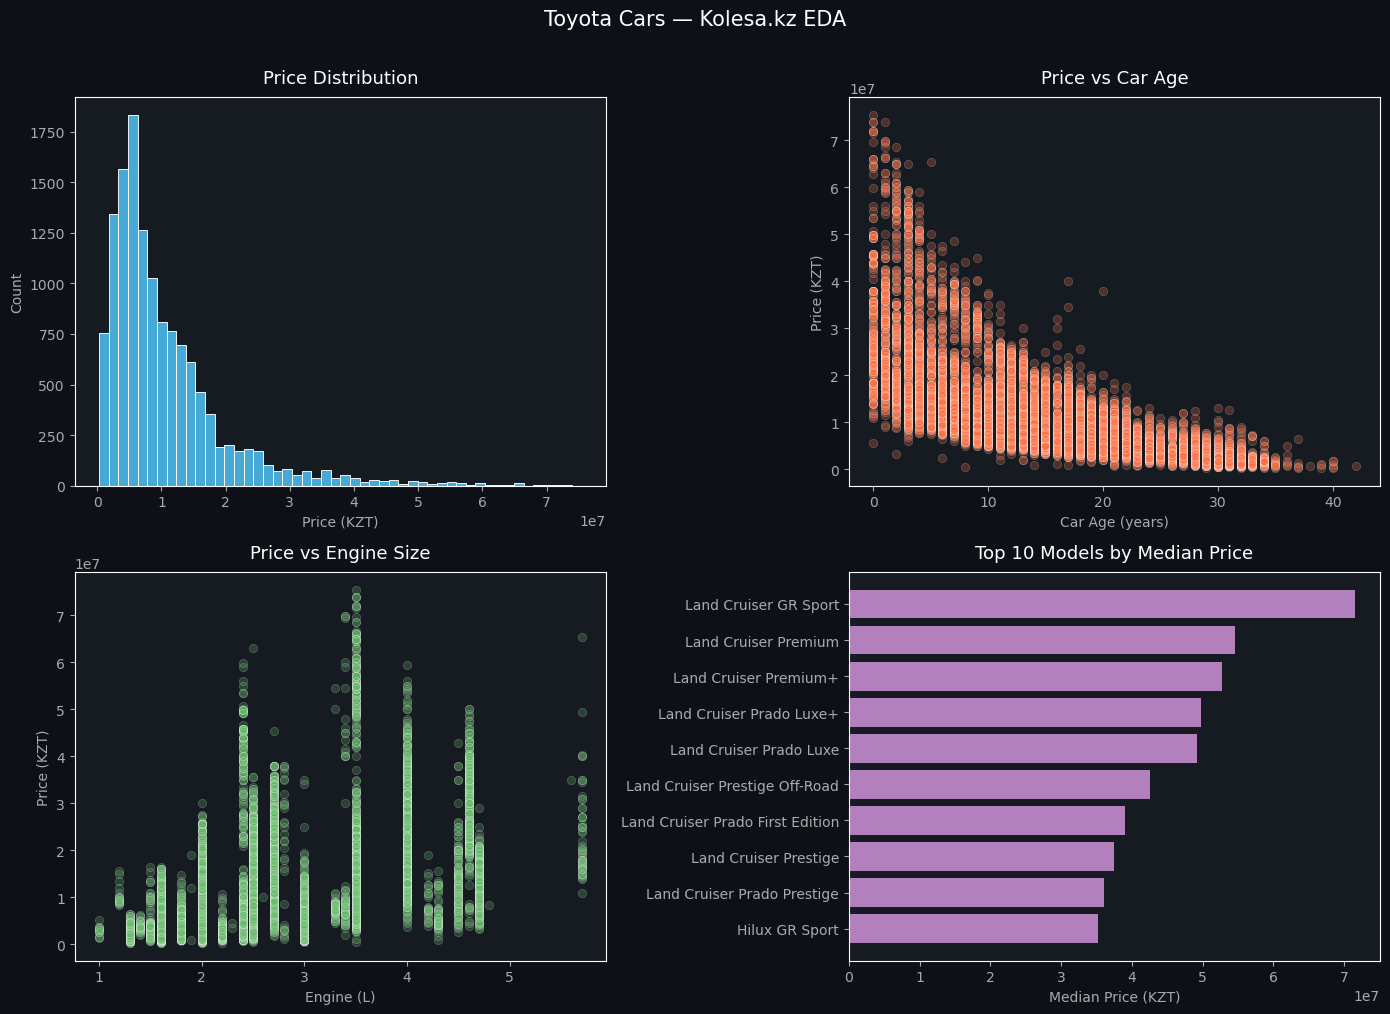

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('dark_background')

colors = ['#4FC3F7', '#FF7043', '#66BB6A', '#CE93D8']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('#0D1117')
for ax in axes.flat:
    ax.set_facecolor('#161B22')

# 1. распределение цен
sns.histplot(df['Price'], bins=50, ax=axes[0,0], color=colors[0], alpha=0.85)
axes[0,0].set_title('Price Distribution', color='white', fontsize=13, pad=10)
axes[0,0].set_xlabel('Price (KZT)', color='#AAAAAA')
axes[0,0].set_ylabel('Count', color='#AAAAAA')
axes[0,0].tick_params(colors='#AAAAAA')

# 2. цена vs возраст
sns.scatterplot(data=df, x='Car_Age', y='Price', alpha=0.25, ax=axes[0,1], color=colors[1])
axes[0,1].set_title('Price vs Car Age', color='white', fontsize=13, pad=10)
axes[0,1].set_xlabel('Car Age (years)', color='#AAAAAA')
axes[0,1].set_ylabel('Price (KZT)', color='#AAAAAA')
axes[0,1].tick_params(colors='#AAAAAA')

# 3. цена vs объём
sns.scatterplot(data=df, x='Engine_Liter', y='Price', alpha=0.25, ax=axes[1,0], color=colors[2])
axes[1,0].set_title('Price vs Engine Size', color='white', fontsize=13, pad=10)
axes[1,0].set_xlabel('Engine (L)', color='#AAAAAA')
axes[1,0].set_ylabel('Price (KZT)', color='#AAAAAA')
axes[1,0].tick_params(colors='#AAAAAA')

# 4. топ 10 моделей по медианной цене
top_models = df.groupby('Model')['Price'].median().nlargest(10)
bars = axes[1,1].barh(top_models.index, top_models.values, color=colors[3], alpha=0.85)
axes[1,1].set_title('Top 10 Models by Median Price', color='white', fontsize=13, pad=10)
axes[1,1].set_xlabel('Median Price (KZT)', color='#AAAAAA')
axes[1,1].tick_params(colors='#AAAAAA')
axes[1,1].invert_yaxis()

plt.suptitle('Toyota Cars — Kolesa.kz EDA', color='white', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### 3.0 Feature engineering

Label-encode categorical columns (`Model`, `Location`) so tree-based models can use them.
Define feature matrix `X` and target `y`.

In [15]:
from sklearn.preprocessing import LabelEncoder

# кодируем категориальные
le_model = LabelEncoder()
le_location = LabelEncoder()

df['Model_enc'] = le_model.fit_transform(df['Model'])
df['Location_enc'] = le_location.fit_transform(df['Location'])

# фичи и таргет
X = df[['Model_enc', 'Location_enc', 'Year', 'Engine_Liter', 'Car_Age']]
y = df['Price']

print(X.shape)
print(y.describe())

(13292, 5)
count    1.329200e+04
mean     1.058418e+07
std      9.613815e+06
min      2.500000e+05
25%      4.500000e+06
50%      7.500000e+06
75%      1.350000e+07
max      7.547747e+07
Name: Price, dtype: float64


### 4.0 Model training

Train/validation split: **80% train / 20% val**.

Comparing three models:
- Linear regression (baseline)
- Random forest
- XGBoost

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    mae = mean_absolute_error(y_val, preds)
    r2 = r2_score(y_val, preds)
    print(f"{name}: MAE = {mae:,.0f} | R² = {r2:.4f}")

Linear Regression: MAE = 3,840,263 | R² = 0.6373
Random Forest: MAE = 1,451,027 | R² = 0.9412
XGBoost: MAE = 1,337,178 | R² = 0.9498


### 4.1 Feature importance

Which features drive price predictions in XGBoost?

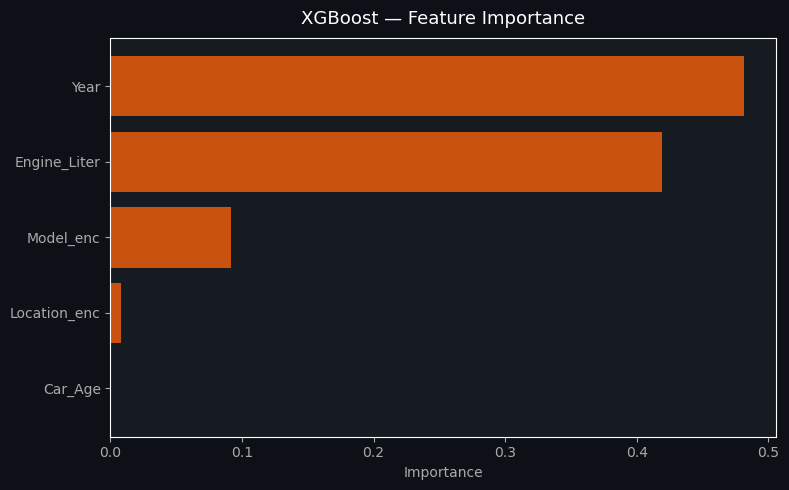

In [19]:
import pandas as pd

best_model = models['XGBoost']

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#161B22')

ax.barh(importance['Feature'], importance['Importance'], color='#eb5d0c', alpha=0.85)
ax.set_title('XGBoost — Feature Importance', color='white', fontsize=13, pad=10)
ax.set_xlabel('Importance', color='#AAAAAA')
ax.tick_params(colors='#AAAAAA')

plt.tight_layout()
plt.show()

### 5.0 Save artifacts

Save the best model and encoders for use in the Streamlit app.

> Run this section after training. These files are in `.gitignore` — generate locally.

In [21]:
import pickle

with open('xgboost_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("Model saved.")

Model saved.


In [22]:
with open('le_model.pkl', 'wb') as f:
    pickle.dump(le_model, f)

with open('le_location.pkl', 'wb') as f:
    pickle.dump(le_location, f)

# список уникальных моделей и городов для дропдаунов
import json

with open('models_list.json', 'w', encoding='utf-8') as f:
    json.dump(sorted(df['Model'].unique().tolist()), f, ensure_ascii=False)

with open('locations_list.json', 'w', encoding='utf-8') as f:
    json.dump(sorted(df['Location'].unique().tolist()), f, ensure_ascii=False)

print("All saved.")

All saved.
